In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d, gaussian_filter
from scipy.signal import wiener
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)

from ezyrb import POD, RBF, Database, Linear, RegularGrid
from ezyrb import ReducedOrderModel as ROM

from scipy.signal import wiener, convolve2d

In [55]:
sigma, ns = 2.2, 3  # 5.5
num_steps = 400
p = 40

dt = 1/num_steps

In [56]:
snapshot = np.load("//files.ad.ife.no/MatPro_files/Florian/Burgers/snapshot01.npy")
n = snapshot.size
X_all = np.zeros((n, num_steps))
t_all = np.linspace(0, 1, num_steps, endpoint=False)

print(n, n**.5)
for i in range(num_steps):
    X_all[:, i] = np.load("//files.ad.ife.no/MatPro_files/Florian/Burgers/snapshot{:02d}.npy".format(i))

10201 101.0


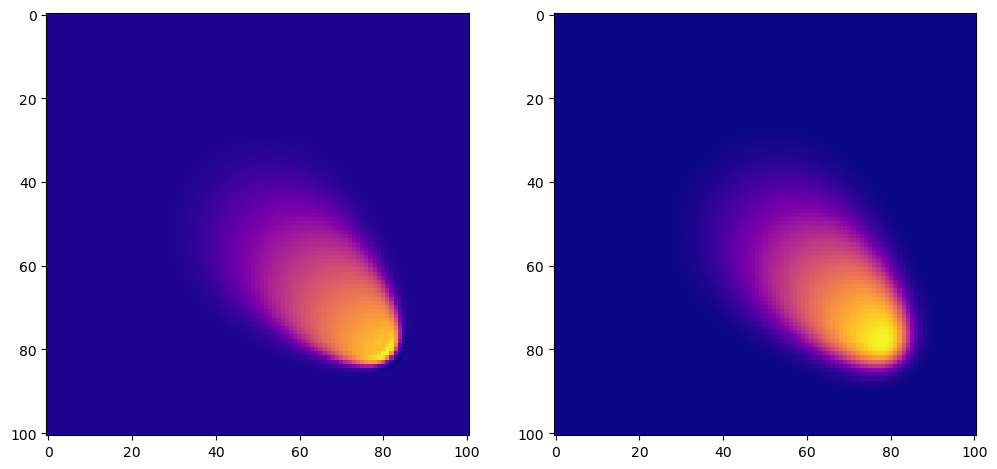

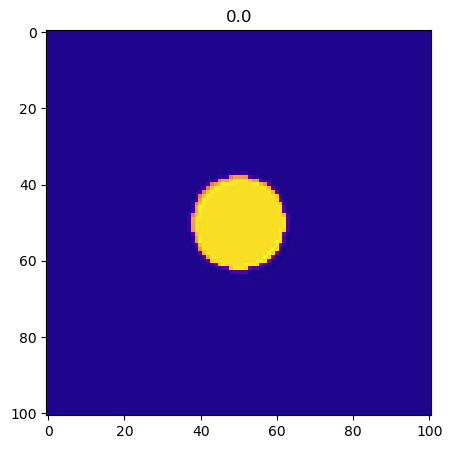

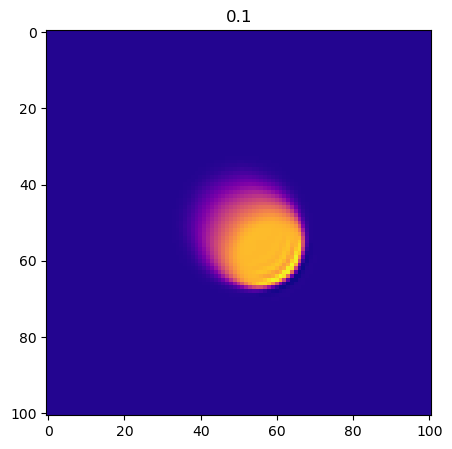

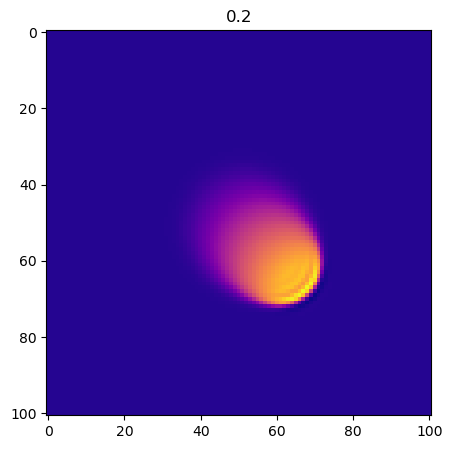

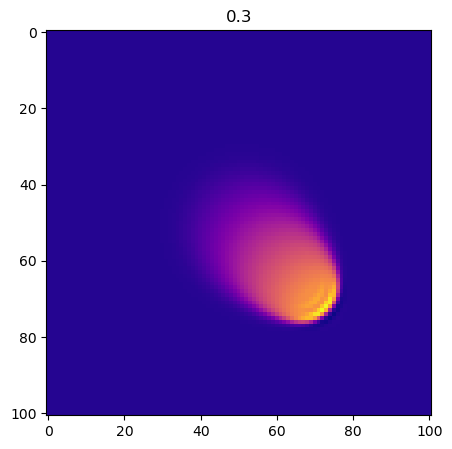

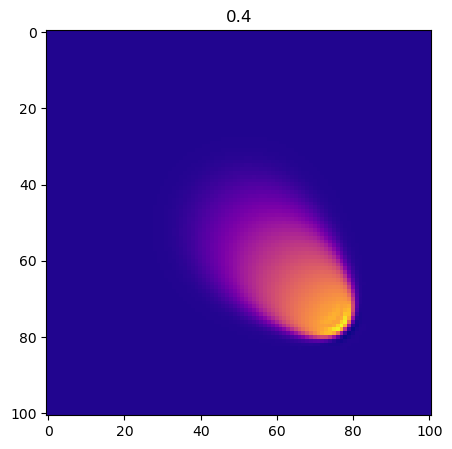

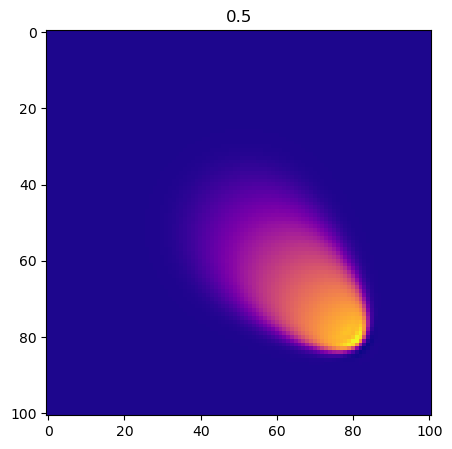

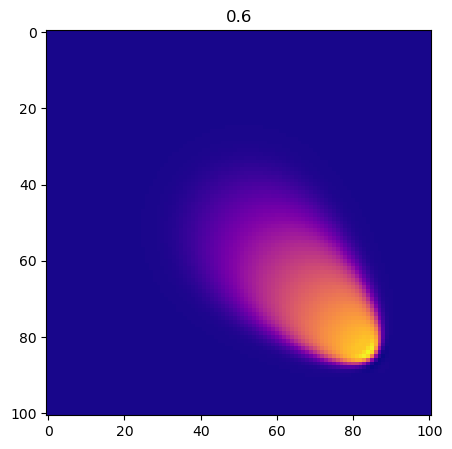

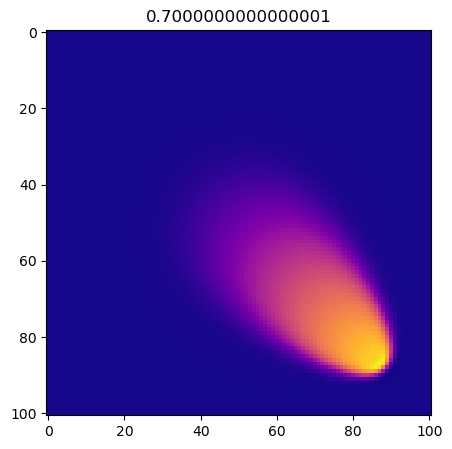

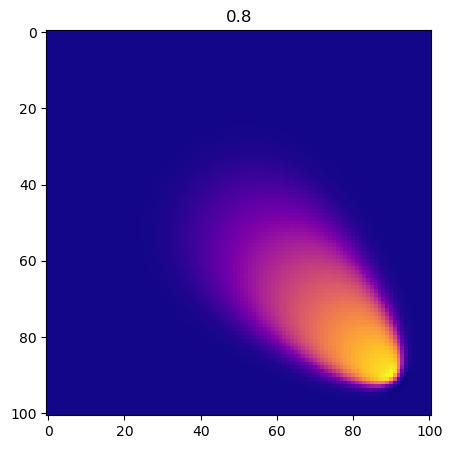

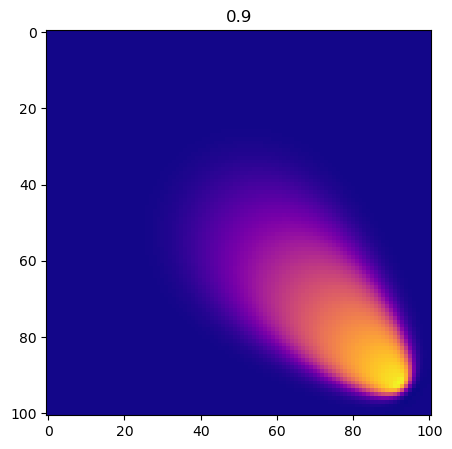

In [57]:
shape = int(n**.5), int(n**.5)
X = X_all[:, ::p]
t = t_all[::p]
X_c = np.zeros_like(X)
for i in range(len(X[0])):
    ss2D = X[:, i].reshape(shape)
    X_c[:, i] = gaussian_filter(ss2D, sigma=sigma, truncate=10).ravel()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(X[:, 200//p].reshape(shape), interpolation="nearest", cmap="plasma")
ax2.imshow(X_c[:, 200//p].reshape(shape), interpolation="nearest", cmap="plasma")
plt.show()

for i in range(10):
    fig, ax1 = plt.subplots(1, 1, figsize=(5, 5))
    ax1.imshow(X[:, i].reshape(shape), interpolation="nearest", cmap="plasma")
    plt.title(t[i])
    plt.show()


In [58]:
U, S, VT = np.linalg.svd(X, False)
U_c, S_c, VT_c = np.linalg.svd(X_c, False)

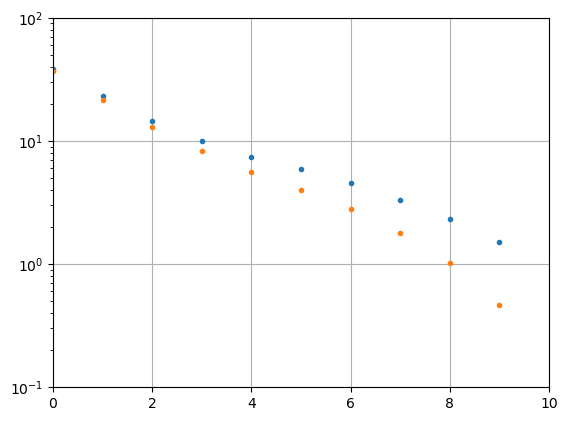

In [59]:
fig, ax = plt.subplots()
ax.plot(S, ".")
ax.plot(S_c, ".")
ax.set_yscale('log')
ax.set_xlim([0, num_steps//p])
ax.set_ylim([1e-1, 100])
plt.grid()

In [60]:
print(X.shape, t[:, None].shape)

(10201, 10) (10, 1)


In [61]:
t_all

array([0.    , 0.0025, 0.005 , 0.0075, 0.01  , 0.0125, 0.015 , 0.0175,
       0.02  , 0.0225, 0.025 , 0.0275, 0.03  , 0.0325, 0.035 , 0.0375,
       0.04  , 0.0425, 0.045 , 0.0475, 0.05  , 0.0525, 0.055 , 0.0575,
       0.06  , 0.0625, 0.065 , 0.0675, 0.07  , 0.0725, 0.075 , 0.0775,
       0.08  , 0.0825, 0.085 , 0.0875, 0.09  , 0.0925, 0.095 , 0.0975,
       0.1   , 0.1025, 0.105 , 0.1075, 0.11  , 0.1125, 0.115 , 0.1175,
       0.12  , 0.1225, 0.125 , 0.1275, 0.13  , 0.1325, 0.135 , 0.1375,
       0.14  , 0.1425, 0.145 , 0.1475, 0.15  , 0.1525, 0.155 , 0.1575,
       0.16  , 0.1625, 0.165 , 0.1675, 0.17  , 0.1725, 0.175 , 0.1775,
       0.18  , 0.1825, 0.185 , 0.1875, 0.19  , 0.1925, 0.195 , 0.1975,
       0.2   , 0.2025, 0.205 , 0.2075, 0.21  , 0.2125, 0.215 , 0.2175,
       0.22  , 0.2225, 0.225 , 0.2275, 0.23  , 0.2325, 0.235 , 0.2375,
       0.24  , 0.2425, 0.245 , 0.2475, 0.25  , 0.2525, 0.255 , 0.2575,
       0.26  , 0.2625, 0.265 , 0.2675, 0.27  , 0.2725, 0.275 , 0.2775,
      

In [72]:
t_new = (t[5]+t[6])/2
xi = np.array([[t_new]])
ind = np.where((t_all-t_new)**2<1e-6)[0][0]
ground_truth = X_all[:, ind]
print(t_new,ind)

0.55 220


In [63]:
reg = RegularGrid()
pod = POD()
db = Database(t[:, None], X.T)
rom = ROM(db, pod, reg)
rom.fit()
standard_ROM = rom.predict(xi)
e = standard_ROM-ground_truth
print(np.min(e), np.max(e))
e1 = np.mean(e**2)**.5

-0.44303521658722167 0.3422448420285995


Text(0.5, 1.0, 'e=0.0195')

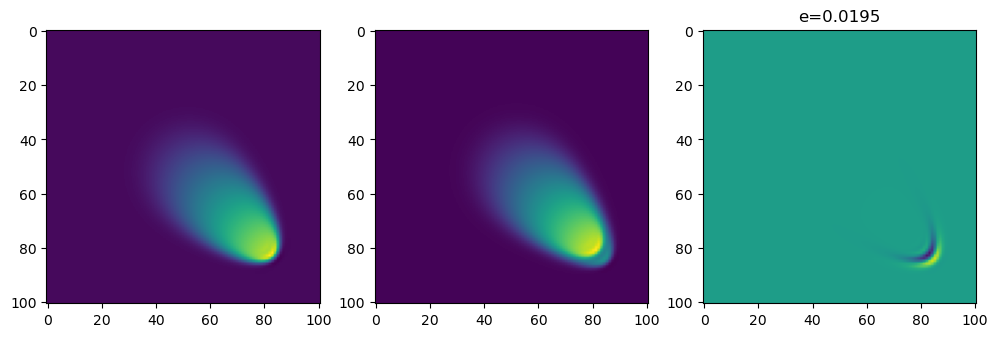

In [64]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 6))
ax1.imshow(ground_truth.reshape(shape))
ax2.imshow(standard_ROM.reshape(shape))
ax3.imshow((standard_ROM-ground_truth).reshape(shape), vmin=-.5, vmax=.4)
ax3.set_title("e={:.4f}".format(np.mean(e**2)**.5))

In [65]:
reg = RegularGrid()
pod = POD()
db = Database(t[:, None], X_c.T)
rom = ROM(db, pod, reg)
rom.fit()
smooth_ROM = rom.predict(xi)

e2 = smooth_ROM-ground_truth
print(np.min(e2), np.max(e2))

-0.38041614359302783 0.214582957526334


Text(0.5, 1.0, 'e=0.0214')

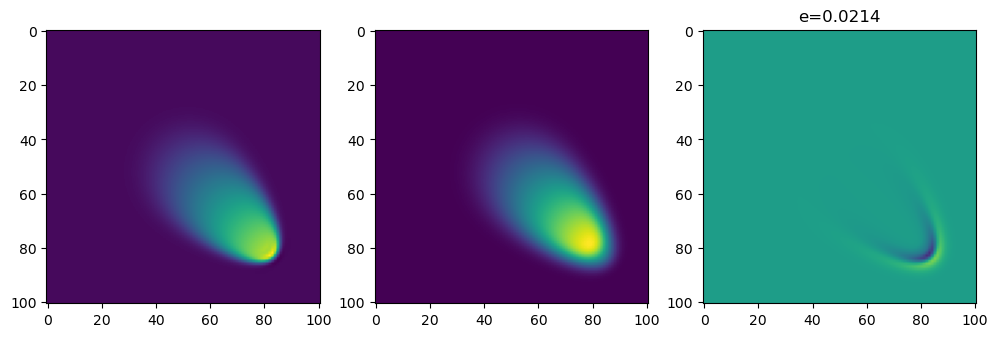

In [66]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 6))
ax1.imshow(ground_truth.reshape(shape))
ax2.imshow(smooth_ROM.reshape(shape))
ax3.imshow((smooth_ROM-ground_truth).reshape(shape), vmin=-.5, vmax=.4)
ax3.set_title("e={:.4f}".format(np.mean(e2**2)**.5))

In [67]:
def sharpen(data, s, limit=False):
    # assert s % 2 == 1, "must be odd"
    data_sharpened = data.copy()
    k = np.array([[0, -1, 0],
                  [-1,  5, -1],
                  [0, -1, 0]])
    for i in range(s):
        data_sharpened = convolve2d(data_sharpened, k,
                                    boundary='symm', mode='same')
        if limit:
            data_sharpened[data_sharpened < 0.0] = 0.0
            data_sharpened[data_sharpened > 1.0] = 1.0
    return data_sharpened

In [68]:
smooth_ROM_sharpened = sharpen(smooth_ROM.copy().reshape(shape), ns)
e3 = smooth_ROM_sharpened-ground_truth.reshape(shape)
print(np.min(e3), np.max(e3))

-0.3523424154953325 0.2703316965774496


Text(0.5, 1.0, 'e=0.0166')

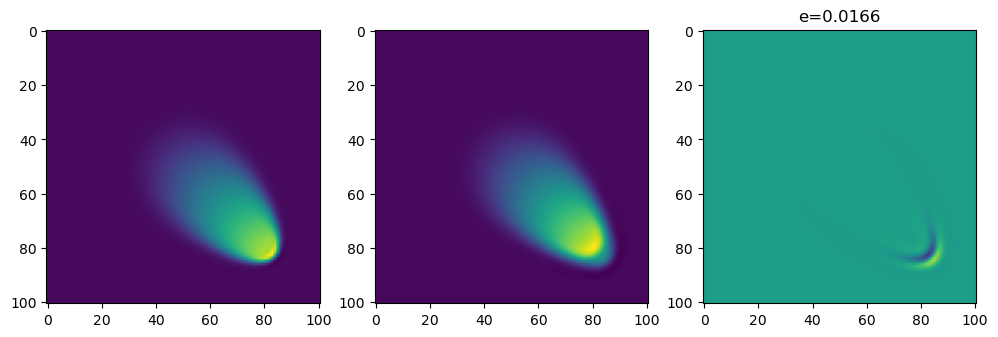

In [69]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 6))
ax1.imshow(ground_truth.reshape(shape))
ax2.imshow(smooth_ROM_sharpened.reshape(shape))
ax3.imshow(e3, vmin=-.5, vmax=.4)
ax3.set_title("e={:.4f}".format(np.mean(e3**2)**.5))

0.0
0.1
0.2
0.30000000000000004
0.4
0.5
0.6000000000000001
0.7000000000000001
0.8
0.9
1.0
1.1
1.2000000000000002
1.3
1.4000000000000001
1.5
1.5 1 15 1 0.017555122696966644
1.6
1.7000000000000002
1.8
1.9000000000000001
2.0
2.1
2.2
2.3000000000000003
2.4000000000000004
2.5
2.6
2.7
2.8000000000000003
2.9000000000000004
3.0
3.1
3.2
3.3000000000000003
3.4000000000000004
3.5
3.6
3.7
3.8000000000000003
3.9000000000000004
4.0
4.1000000000000005
4.2
4.3
4.4
4.5
4.6000000000000005
4.7
4.800000000000001
4.9
5.0


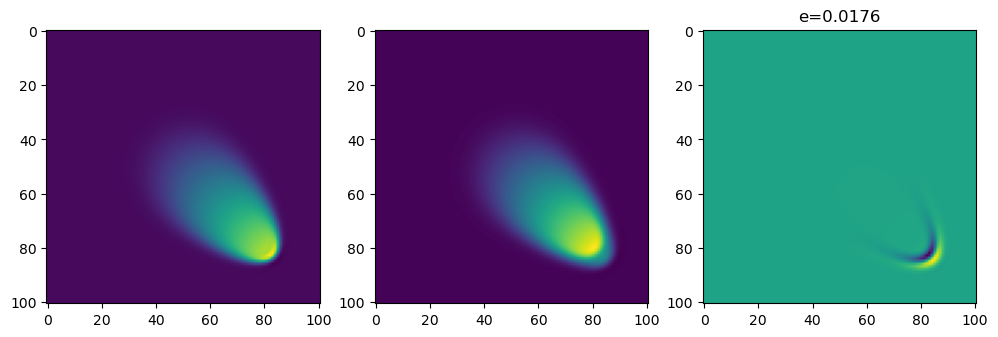

In [45]:
shape = int(n**.5), int(n**.5)
X = X_all[:, ::p]
t = t_all[::p]
X_c = np.zeros_like(X)

n_sharpenings = [0, 1, 2, 3, 4, 5]

sigmas = np.linspace(0, 5, 51)
n_sharpenings = [0, 1, 2, 3, 4, 5]

e2 = np.zeros((len(sigmas),))
e3 = np.zeros((len(sigmas), len(n_sharpenings)))
xi = np.array([[t_new]])

for j, s in enumerate(sigmas):
    print(s)
    for i in range(len(X[0])):
        ss2D = X[:, i].reshape(shape)
        X_c[:, i] = gaussian_filter(ss2D, sigma=s, truncate=10).ravel()

    reg = RegularGrid()
    pod = POD()
    db = Database(t[:, None], X_c.T)
    rom = ROM(db, pod, reg)
    rom.fit()
    smooth_ROM = rom.predict(xi)

    e2[j] = np.mean((smooth_ROM-ground_truth)**2)**.5
    
    for k, ns in enumerate(n_sharpenings):
        p_sharp = sharpen(smooth_ROM.reshape(shape), ns).ravel()
        e3[j, k] = np.mean((p_sharp-ground_truth)**2)**.5
        
        if s == 1.5 and ns == 1:
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 6))
            ax1.imshow(ground_truth.reshape(shape))
            ax2.imshow(p_sharp.reshape(shape))
            ax3.imshow((p_sharp-ground_truth).reshape(shape))
            ax3.set_title("e={:.4f}".format(np.mean((p_sharp-ground_truth)**2)**.5))
            print(s, ns, j, k, e3[j, k])

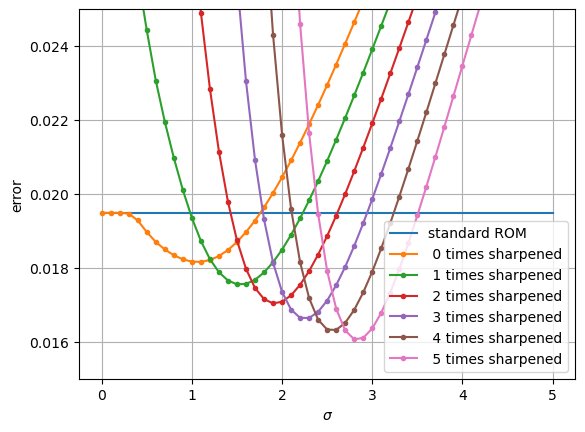

In [54]:
#plt.plot(sigmas, e2, label="smooth ROM")
plt.plot(sigmas, np.ones_like(e2)*e1, label="standard ROM")
for k, ns in enumerate(n_sharpenings):
    plt.plot(sigmas, e3[:, k], marker=".", label="{:2d} times sharpened".format(ns))
plt.legend()
plt.ylim([0.015, .025])
plt.xlabel("$\sigma$")
plt.ylabel("error")
plt.grid()

In [19]:
# TODO: error vs time
# TODO: sharpening!
# TODO: find best error, correlate with sigma
# 1D case?

2.2	5.474665459572414


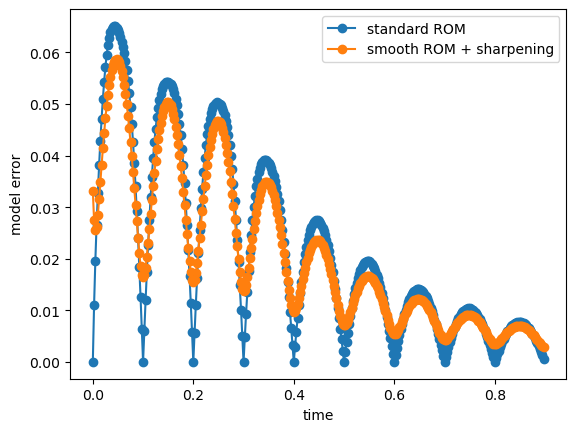

In [71]:
sigma, ns = 4.5, 12  # 1.67
sigma, ns = 3.5, 7  # 3.1
sigma, ns = 3, 5  # 3.05
sigma, ns = 2.5, 4  # 5.5
#sigma, ns = 2, 2  # 2.94
#sigma, ns = 1.75, 1  # -1.4

sigma, ns = 1.3, 1  # 4.5
sigma, ns = 1.8, 2  # 5.2
sigma, ns = 2.2, 3  # 5.5
#sigma, ns = 2.5, 4  # 5.5

for sigma in [2.2]:  # sigmas
    for i in range(len(X[0])):
        ss2D = X[:, i].reshape(shape)
        X_c[:, i] = gaussian_filter(ss2D, sigma=sigma, truncate=10).ravel()

    reg = RegularGrid()
    pod = POD()
    db = Database(t[:, None], X.T)
    standard_rom = ROM(db, pod, reg)
    standard_rom.fit()

    reg = RegularGrid()
    pod = POD()
    db = Database(t[:, None], X_c.T)
    smooth_rom = ROM(db, pod, reg)
    smooth_rom.fit()

    e_t = np.zeros((len(t_all), 3))
    for j, _t_ in enumerate(t_all[:-40]):
        xi = [_t_]
        _ground_truth = X_all[:, j]
        p_standard_rom = standard_rom.predict(xi)
        p_smooth_ROM = smooth_rom.predict(xi)

        p_sharp = sharpen(p_smooth_ROM.reshape(shape), ns).ravel()
        e_t[j, 0] = np.mean((p_standard_rom-_ground_truth)**2)**.5
        e_t[j, 1] = np.mean((p_smooth_ROM-_ground_truth)**2)**.5
        e_t[j, 2] = np.mean((p_sharp-_ground_truth)**2)**.5
    plt.plot(t_all[:-40], e_t[:-40, 0], marker="o", label="standard ROM")
    #plt.plot(t_all[:-40], e_t[:-40, 1], marker="o", label="smooth ROM")
    plt.plot(t_all[:-40], e_t[:-40, 2], marker="o", label="smooth ROM + sharpening")
    plt.legend()
    plt.xlabel("time")
    plt.ylabel("model error")
    #print(np.mean(e_t[:-40, 0]))
    #print(np.mean(e_t[:-40, 2]))
    #print((1-np.mean(e_t[:-40, 2]/e_t[:-40, 0]))*100)
    print(sigma, (1-np.mean(e_t[:-40, 2])/np.mean(e_t[:-40, 0]))*100, sep="\t")